# Preparación de Datos y Análisis Exploratorio

## Descripción General del Conjunto de Datos

El [Conjunto de Datos de Enfermedad Tiroidea](https://www.kaggle.com/datasets/emmanuelfwerr/thyroid-disease-data) proviene del Repositorio UCI de Machine Learning y contiene registros de pacientes con mediciones de la función tiroidea.

**Contexto Clínico:**
La glándula tiroides produce hormonas (T3, T4) que regulan el metabolismo. La disfunción tiroidea se manifiesta como:
- **Hipertiroidismo**: Tiroides hiperactiva, producción excesiva de hormonas (síntomas: pérdida de peso, ritmo cardíaco acelerado, ansiedad)
- **Hipotiroidismo**: Tiroides hipoactiva, producción insuficiente de hormonas (síntomas: fatiga, aumento de peso, depresión)

Mediciones de laboratorio clave incluyen:
- **TSH** (Hormona Estimulante de la Tiroides): Alta en hipotiroidismo, baja en hipertiroidismo
- **T3** (Triyodotironina): Hormona tiroidea activa
- **T4** (Tiroxina): Principal hormona tiroidea, medida como TT4 (total) o FTI (Índice de Tiroxina Libre)
- **TBG** (Globulina Transportadora de Tiroxina): Proteína que transporta las hormonas tiroideas en sangre

## Carga de Datos y ETL

En este notebook, realizamos algo de **Preparación de Datos (ETL)**: principalmente seleccionar las columnas a usar (eliminando las que no tienen semántica útil) y simplificar las clases objetivo. Estos pasos son independientes de la distribución de los datos.

Esto es distinto del **Preprocesamiento del Modelo** (que manejaremos en notebooks posteriores). El preprocesamiento implica aprender de los datos (p. ej., imputación por media, escalado estándar) y **debe** ajustarse solo sobre el conjunto de entrenamiento para evitar la fuga de datos.

In [ ]:
import kagglehubfrom pathlib import Pathdataset_path = Path(kagglehub.dataset_download("emmanuelfwerr/thyroid-disease-data"))

/media/DIURNOext4/alejandro/wip-clase/PIA-SAA/example_repos/thyroid/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import pandas as pddf = pd.read_csv(dataset_path / "thyroidDF.csv")df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9172 entries, 0 to 9171
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  9172 non-null   int64  
 1   sex                  8865 non-null   str    
 2   on_thyroxine         9172 non-null   str    
 3   query_on_thyroxine   9172 non-null   str    
 4   on_antithyroid_meds  9172 non-null   str    
 5   sick                 9172 non-null   str    
 6   pregnant             9172 non-null   str    
 7   thyroid_surgery      9172 non-null   str    
 8   I131_treatment       9172 non-null   str    
 9   query_hypothyroid    9172 non-null   str    
 10  query_hyperthyroid   9172 non-null   str    
 11  lithium              9172 non-null   str    
 12  goitre               9172 non-null   str    
 13  tumor                9172 non-null   str    
 14  hypopituitary        9172 non-null   str    
 15  psych                9172 non-null   str    
 16 

El conjunto de datos original tiene más de 30 categorías de diagnóstico. Las simplificamos en tres grupos clínicamente significativos para facilitar la interpretación del modelo y reducir el desequilibrio de clases.

In [ ]:
import numpy as np# Preserve original labels for traceability and idempotencyif "target_raw" not in df.columns:    df["target_raw"] = df["target"]df["target"] = np.select(    [        df["target_raw"].str.contains("[A-D]", na=False),         df["target_raw"].str.contains("[E-H]", na=False)    ],    ["hyperthyroid", "hypothyroid"],    default="negative")print(f"Dataset shape: {df.shape[0]} samples, {df.shape[1]} features")print("\nTarget distribution:")display(pd.DataFrame({    'Count': df['target'].value_counts(),    'Percentage (%)': (df['target'].value_counts(normalize=True) * 100).round(1)}))

Dataset shape: 9172 samples, 32 features

Target distribution:


,Count,Percentage (%)
target,,
negative,8264,90.1
hypothyroid,667,7.3
hyperthyroid,241,2.6


La distribución de clases revela un desequilibrio significativo: aproximadamente el 90% de los casos son "negativos" (sin disfunción tiroidea). Esto es típico en conjuntos de datos de cribado médico donde la prevalencia de la enfermedad es baja. **Este desequilibrio influirá en nuestra elección de métricas de evaluación** y potencialmente requerirá manejo especializado durante el entrenamiento del modelo.

### Estructura del Conjunto de Datos y Limpieza

### Tipos de Características

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9172 entries, 0 to 9171
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  9172 non-null   int64  
 1   sex                  8865 non-null   str    
 2   on_thyroxine         9172 non-null   str    
 3   query_on_thyroxine   9172 non-null   str    
 4   on_antithyroid_meds  9172 non-null   str    
 5   sick                 9172 non-null   str    
 6   pregnant             9172 non-null   str    
 7   thyroid_surgery      9172 non-null   str    
 8   I131_treatment       9172 non-null   str    
 9   query_hypothyroid    9172 non-null   str    
 10  query_hyperthyroid   9172 non-null   str    
 11  lithium              9172 non-null   str    
 12  goitre               9172 non-null   str    
 13  tumor                9172 non-null   str    
 14  hypopituitary        9172 non-null   str    
 15  psych                9172 non-null   str    
 16 

El conjunto de datos contiene:
- **Características numéricas**: `age`, `TSH`, `T3`, `TT4`, `T4U`, `FTI`, `TBG` (mediciones continuas)
- **Características binarias**: La mayoría de las columnas no numéricas son categóricas binarias con valores "f" y "t", representando "falso" y "verdadero", respectivamente, como `on_thyroxine`, `pregnant`, `thyroid_surgery`. Estas columnas pueden convertirse a variables binarias numéricas (0 y 1) para facilitar su uso en el modelo.
- **Características categóricas**: `sex` (M/F). Esta columna tiene ~300 valores faltantes. Dado que pandas almacena las columnas de cadenas de texto como tipo `objeto`, estos valores faltantes se representan como `np.nan` (números de punto flotante). Esta mezcla de tipos (cadenas + flotantes) requerirá conversión explícita a cadena en nuestros Pipelines de modelado para prevenir errores de verificación de tipos en librerías como CatBoost.
- **Banderas de medición**: Cada prueba numérica tiene una columna `_measured` correspondiente que indica si se realizó la prueba.
- **patient_id** es un identificador que no proporciona información relevante, por lo que se eliminará.
- **referral_source** (valores como SVI, SVHC, STMW, SVHD) indica de dónde vino el paciente (p. ej., una clínica especializada, un médico de cabecera u otro departamento hospitalario).

`referral_source` puede ser predictivo debido a una probabilidad a priori (los pacientes derivados desde una "Clínica de Tiroides" especializada (STMW) podrían tener un 50% de probabilidad de estar enfermos, mientras que los pacientes de un "Chequeo General" (SVI) podrían tener solo un 1%). Aunque no es causal y es específico de este conjunto de datos, asumiremos que nuestro modelo debe predecir en un entorno diferente y nos enfocaremos en los datos biológicos.

In [ ]:
df.drop(columns=['patient_id', 'referral_source'], inplace=True)

### Nota de Reproducibilidad: La Función de Carga
Para garantizar que estos pasos de limpieza sean reproducibles en nuestros futuros notebooks de modelado, hemos encapsulado la lógica anterior (carga, simplificación del objetivo y eliminación de identificadores) en una función utilitaria dedicada:

`src.data_loader.load_thyroid_data_3_classes`

junto con la división entrenamiento/prueba. Esta función será el punto de entrada para todos los experimentos posteriores, garantizando una calidad de datos uniforme.

## Análisis Exploratorio de Datos

Ahora que tenemos un conjunto de datos limpio y estructurado, procedemos con el **EDA** sobre el conjunto de datos completo para entender sus propiedades e informar nuestra estrategia de preprocesamiento.

### Distribuciones de Características Numéricas

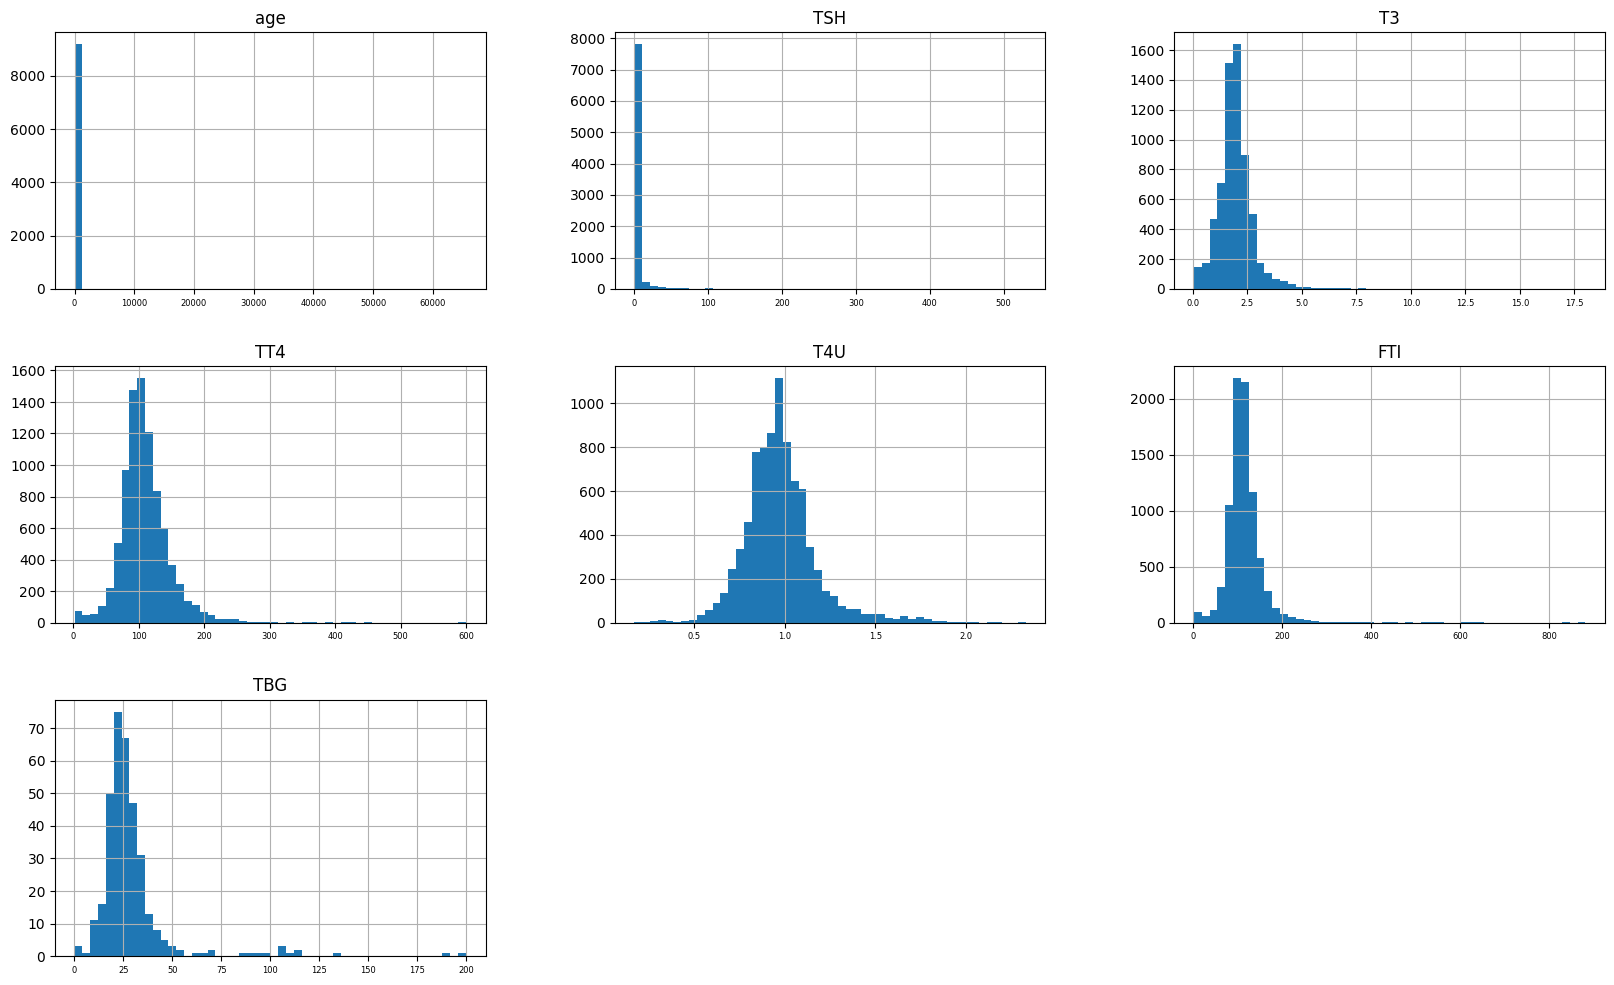

In [ ]:
import matplotlib.pyplot as plt_ = df.hist(bins=50, figsize=(20, 12), xlabelsize=6) 

- **Integridad de Datos y Valores Atípicos**: La distribución de edad contiene errores de entrada de datos graves, con valores máximos superiores a 60,000. Estos valores imposibles indican errores de captura que requieren filtrado basado en umbrales (p. ej., limitar la edad a 100).
- **Sesgo y Transformación**: TSH exhibe un sesgo extremo hacia la derecha, con la gran mayoría de la densidad concentrada cerca de cero y una larga cola que se extiende hasta 500+. Esto sugiere una distribución no normal de base donde una transformación logarítmica será necesaria para estabilizar la varianza en modelos lineales.
- **Características Gaussianas**: Los marcadores de función tiroidea (T3, TT4, T4U y FTI) se aproximan a distribuciones normales. Esto es esperado en métricas de pruebas médicas con la mayoría de muestras negativas: representa a la población, **normalmente** los pacientes tendrán métricas alrededor de la media, y las mediciones extremas son poco frecuentes y frecuentemente serán indicadores de enfermedad. Sin embargo, TT4 y FTI retienen valores atípicos visibles hacia el lado derecho, que probablemente representan casos patológicos genuinos (hipertiroideos) en lugar de ruido.
- **Escasez de Características**: El histograma de TBG muestra recuentos de frecuencia insignificantes en comparación con las otras características (máximo ~70 vs ~8000), confirmando que esta variable sufre de ausencias masivas y probablemente no es adecuada para el modelado.

### Tratamiento de la Edad

In [ ]:
# valores of age over 100df[df['age'] > 100]

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,target,target_raw
2976,455,F,f,f,f,f,f,f,f,f,...,t,118.0,t,1.13,t,104.0,f,NaN,negative,-
5710,65511,M,f,f,f,f,f,f,f,f,...,t,113.0,t,1.08,t,104.0,f,NaN,negative,-
6392,65512,M,f,f,f,f,f,f,f,f,...,t,112.0,t,0.84,t,133.0,f,NaN,negative,-
8105,65526,F,f,f,f,f,f,f,f,f,...,t,132.0,t,1.02,t,129.0,f,NaN,negative,-


<Axes: >

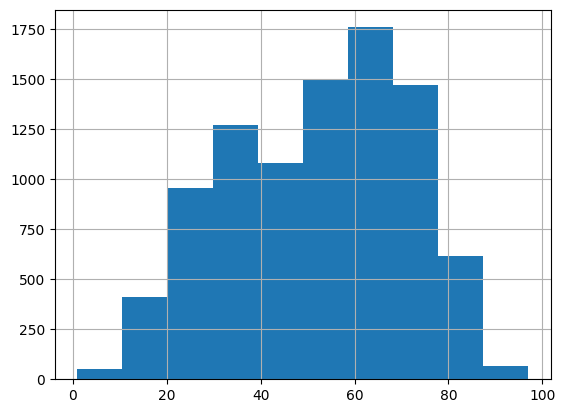

In [ ]:
df[df['age'] < 100]['age'].hist()

Vemos que hay 4 filas con valores de edad absurdos que se considerarán errores de entrada de datos, por lo que se tratarán como valores faltantes. Una vez eliminados estos valores, la distribución de edad es bastante simétrica y no tiene valores atípicos.

In [ ]:
df.loc[df['age'] > 100, 'age'] = np.nan 

Aún tendremos que decidir cómo tratar los valores faltantes de edad (imputación vs. dejar como NaN) según la elección del modelo.

### Tratamiento de TSH

Max Age is now: 97.0
TSH skewness before: 12.92
TSH skewness after log: 1.94


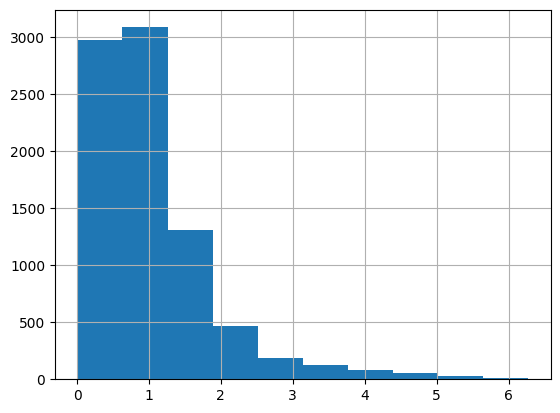

In [ ]:
# We aplicar a log transformation. # We add +1 because log(0) is undefined, and TSH can be 0.# Formula: TSH_log = log(TSH + 1)df['TSH_log'] = np.log1p(df['TSH'])print(f"Max Age is now: {df['age'].max()}")print(f"TSH skewness before: {df['TSH'].skew():.2f}")print(f"TSH skewness after log: {df['TSH_log'].skew():.2f}")_ = df['TSH_log'].hist()

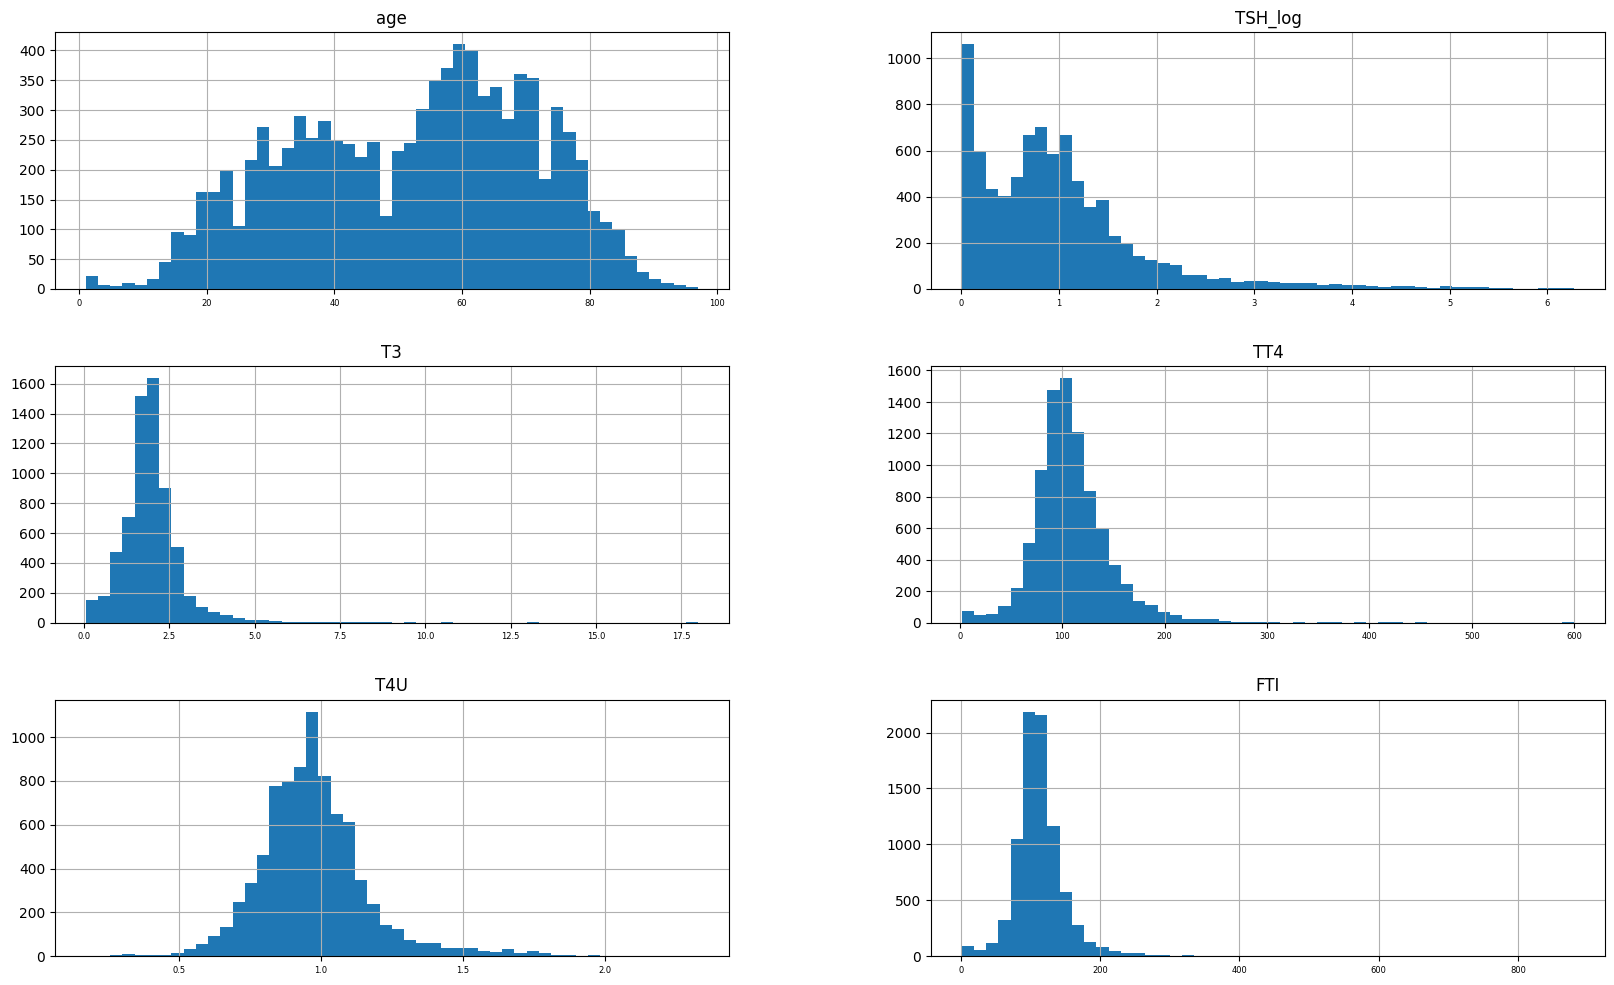

In [ ]:
cleaned_cols = ['age', 'TSH_log', 'T3', 'TT4', 'T4U', 'FTI']_ = df[cleaned_cols].hist(bins=50, figsize=(20, 12), xlabelsize=6) 

## Análisis de Valores Faltantes

In [ ]:
missing_counts = df.isnull().sum()missing_percentages = (df.isnull().sum() / len(df) * 100).round(1)missing_df = pd.DataFrame({    'missing_count': missing_counts,    'missing_percentage': missing_percentages})missing_df[missing_df['missing_count'] > 0].sort_values('missing_percentage', ascending=False)

,missing_count,missing_percentage
TBG,8823,96.2
T3,2604,28.4
TSH_log,842,9.2
TSH,842,9.2
T4U,809,8.8
FTI,802,8.7
TT4,442,4.8
sex,307,3.3
age,4,0.0


### Comprensión de los Patrones de Ausencia

No todos los valores faltantes son iguales. En este conjunto de datos, distinguimos entre dos mecanismos fundamentales que requieren estrategias de manejo diferentes:

#### 1. "Ausencia Informativa" (TBG - Globulina Transportadora de Tiroxina)
*   **Tasa de Ausencia:** Extrema (>90%).
*   **Mecanismo:** **MNAR (Faltante No al Azar)**. La ausencia en sí misma es una característica.
    *   **Contexto:** Los médicos no ordenan esta costosa prueba para pacientes estándar. Típicamente es un "desempate" ordenado solo cuando las pruebas básicas (T3/T4) son contradictorias o límite.
    *   **La Trampa:** Los pocos valores que *sí* tenemos probablemente sufren **Sesgo de Selección** (sesgados hacia casos complejos/enfermos). Imputar el 90% restante basándose en esta minoría sesgada introduciría ruido significativo.
*   **Estrategia:** **Valor = Irrelevante, Bandera = Crítica.**
    *   Confiamos más en la *ausencia* de la prueba que en un valor estimado.
    *   **Acción:** Eliminar la columna numérica (o imputar un marcador como 0/-1) y confiar en la bandera binaria `TBG_measured` para capturar la "intuición del médico".

#### 2. "Ausencia Incidental" (T3, TSH, T4)
*   **Tasa de Ausencia:** Moderada (~10-30%).
*   **Mecanismo:** **MAR (Faltante al Azar)**.
    *   **Contexto:** Estas son pruebas de panel estándar. Si T3 falta, a menudo es porque T4/TSH fueron suficientes para el diagnóstico (una regla clínica predecible), o por problemas aleatorios de laboratorio. La ausencia probablemente está explicada por otras variables observadas (como los niveles de T4).
*   **Estrategia:** **Valor = Crítico, Bandera = Redundante.**
    *   Creemos que estos pacientes *tienen* un valor "normal" o "predecible" que simplemente no medimos.
    *   **Acción:** Imputar el valor (usando mediana o imputación agrupada por Sexo) para restaurar el perfil biológico. La bandera `_measured` es menos útil aquí y puede eliminarse para modelos basados en árboles.

### Análisis de Banderas de Medición

In [ ]:
# Verify relationship between _measured flags and NaN valoresmeasured_cols = [col for col in df.columns if col.endswith('_measured')]for col in measured_cols:    base_col = col.replace('_measured', '')    if base_col in df.columns:        measured_true = (df[col] == 't').sum()        has_value = df[base_col].notna().sum()        print(f"{base_col}: measured='t' count = {measured_true}, non-null count = {has_value}")

TSH: measured='t' count = 8330, non-null count = 8330
T3: measured='t' count = 6568, non-null count = 6568
TT4: measured='t' count = 8730, non-null count = 8730
T4U: measured='t' count = 8363, non-null count = 8363
FTI: measured='t' count = 8370, non-null count = 8370
TBG: measured='t' count = 349, non-null count = 349


Verificamos que las banderas `_measured` indican correctamente los valores faltantes en las características numéricas correspondientes. Por ejemplo, si `TSH_measured` es 0, entonces `TSH` es NaN. Esto significa que las banderas son lógicamente redundantes: contienen la misma información de ausencia ya codificada por `NaN` en la columna numérica.

Sin embargo, si las banderas deben eliminarse depende de la **familia del modelo** y la **estrategia de valores faltantes**, porque después del preprocesamiento la redundancia puede desaparecer:

- **Si imputas valores numéricos (Regresión Logística, la mayoría de los modelos lineales):**
  - Una vez que imputes, la columna numérica ya no contiene `NaN`, por lo que el modelo pierde la información de que "este valor estaba originalmente faltante".
  - En ese caso, una bandera `_measured` puede añadir señal útil, porque preserva el patrón de ausencia separado del valor imputado. Esta es exactamente la justificación detrás del `SimpleImputer(add_indicator=True)` de sklearn, que añade indicadores de ausencia explícitamente. Sin embargo, en este caso, la información ya está presente en las columnas `_measured`, así que podemos simplemente conservarlas en lugar de añadir nuevos indicadores.

- **Si el modelo maneja `NaN` de forma nativa (random forest en Scikit-learn ≥ 1.4, XGBoost/CatBoost):**
  - Conservar tanto la característica numérica con `NaN` *como* la bandera `_measured` es generalmente redundante.
  - Recomendado: conservar la característica numérica como `NaN` y **eliminar** las banderas `_measured` (incluyendo `TBG_measured`), a menos que quieras interpretabilidad explícita sobre "prueba ordenada".

- **Caso especial: TBG**
  - Aunque `TBG_measured` es redundante con `NaN` *antes* del preprocesamiento, puede ser la **representación más significativa** de TBG en este conjunto de datos, ya que el evento "se ordenó la prueba" puede ser más informativo que cualquier valor imputado de TBG (ausencia informativa / sesgo de selección).

- **Redes Neuronales**
  - Las redes neuronales no pueden consumir `NaN` directamente, por lo que la imputación es obligatoria; por tanto, conservar las banderas `_measured` suele ser una buena idea (actúan como una máscara / indicador de ausencia) para evitar tratar los valores imputados como mediciones reales.

### Distribuciones de Características por Clase (Datos Limpios)
Ahora visualizamos las distribuciones en relación con la clase objetivo.

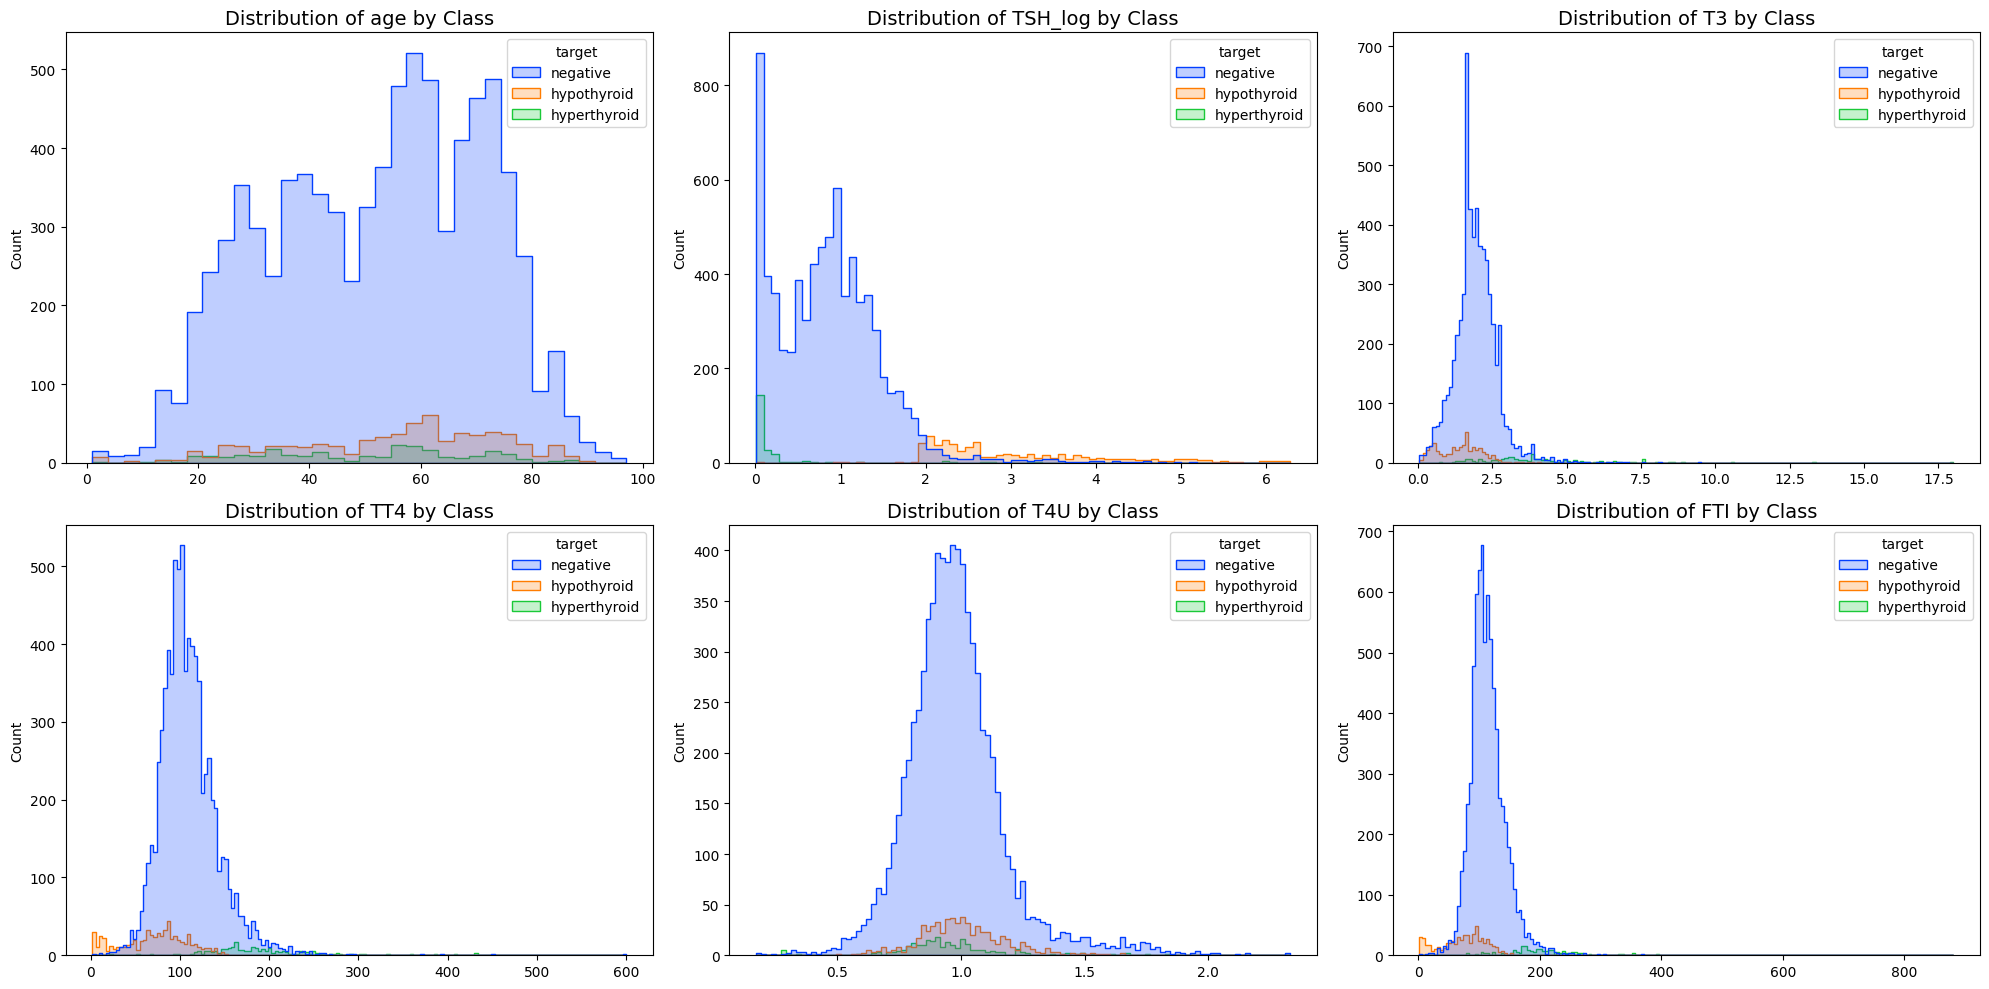

In [ ]:
from src.visualization import plot_histograms_by_classplot_histograms_by_class(df, target_col='target', columns=cleaned_cols)

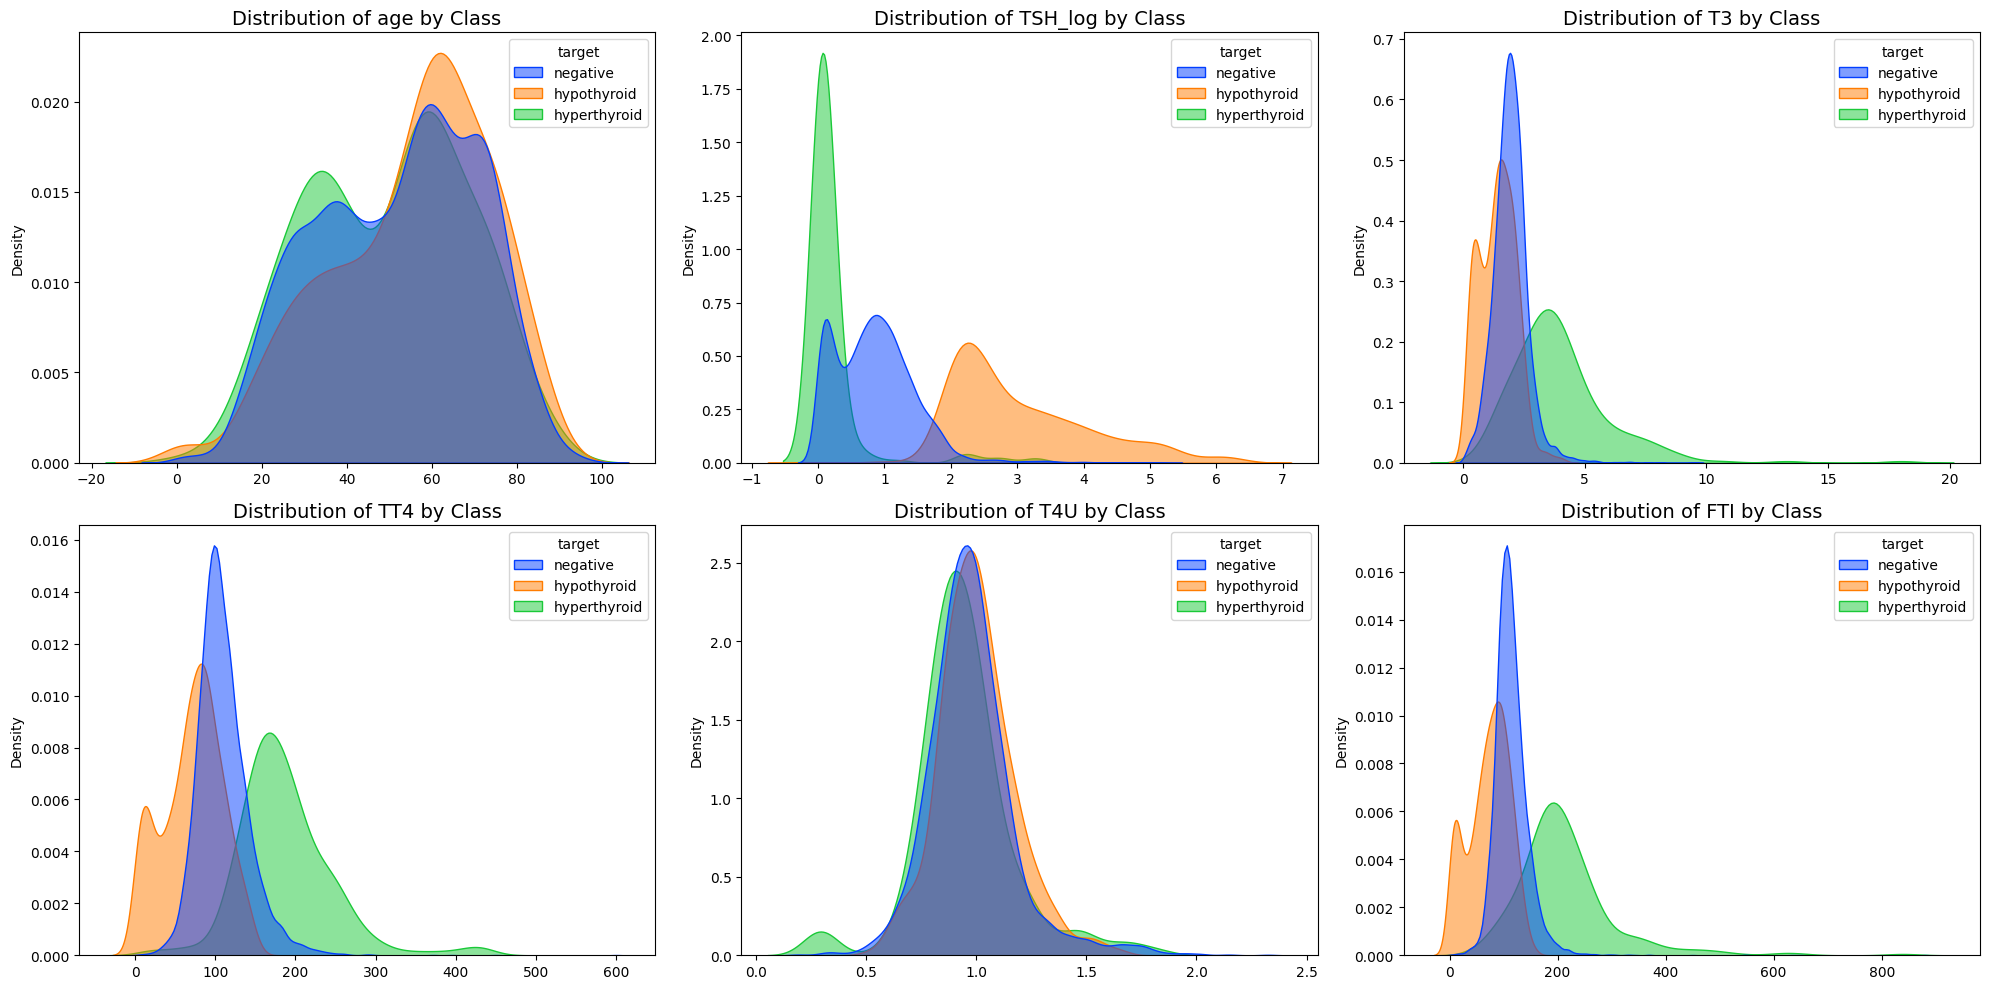

In [ ]:
from src.visualization import plot_histograms_by_classplot_histograms_by_class(df, target_col='target', columns=cleaned_cols, kde=True)

### Análisis de Distribuciones de Características por Clase
En esta sección, analizamos cómo las distribuciones de características difieren entre las tres clases diagnósticas (`Negativo`, `Hipotiroideo`, `Hipertiroideo`). Este paso es crítico para identificar qué características poseen el mayor **poder discriminativo** para nuestro modelo.

#### Una Nota sobre la Visualización: Histogramas vs. KDE
Presentamos dos vistas de los datos para manejar el desequilibrio extremo de clases en este conjunto de datos:

1.  **Histogramas en bruto:** Estos muestran los *recuentos absolutos*. Aunque verídicos, el enorme número de casos "Negativos" (miles) visualmente abruma los casos patológicos (frecuentemente menos de 100), haciendo que la clase "Hipertiroideo" aparezca como ruido apenas visible.
2.  **Estimación de Densidad por Kernel (KDE):** Visualiza la *densidad de probabilidad* (forma) de los datos en lugar de conteos en bruto. Piénsalo como suavizar los bloques del histograma en una curva continua.
    * **Por qué ayuda aquí:** Usamos normalización independiente (`common_norm=False`). Esto escala el área de la curva "Hipertiroideo" para que coincida con la curva "Negativo", permitiéndonos comparar la **ubicación y forma** de las distribuciones como iguales, independientemente de su tamaño de muestra.

#### Perspectivas Clave del Análisis
* **Predictores Más Fuertes (Separación):**
    * **TSH (Transformado Logarítmicamente):** Muestra la separación más clara. La clase **Hipotiroideo** forma un cluster distinto en el extremo alto, mientras que los casos **Hipertiroideo** están comprimidos cerca de cero (suprimidos).
    * **FTI y TT4:** Exhiben una relación inversa fuerte con TSH. Los pacientes **Hipertiroideoss** se desplazan significativamente hacia la derecha (niveles elevados), mientras que los pacientes **Hipotiroideos** se desplazan hacia la izquierda (niveles deprimidos).
* **Predictores Débiles (Superposición):**
    * **Edad y T4U:** Estas características muestran una superposición topológica significativa. Las curvas de densidad para pacientes enfermos y sanos son casi idénticas, sugiriendo que los niveles de edad y T4U por sí solos no son indicadores confiables del estado de la enfermedad tiroidea en esta población.

## Análisis de Correlación

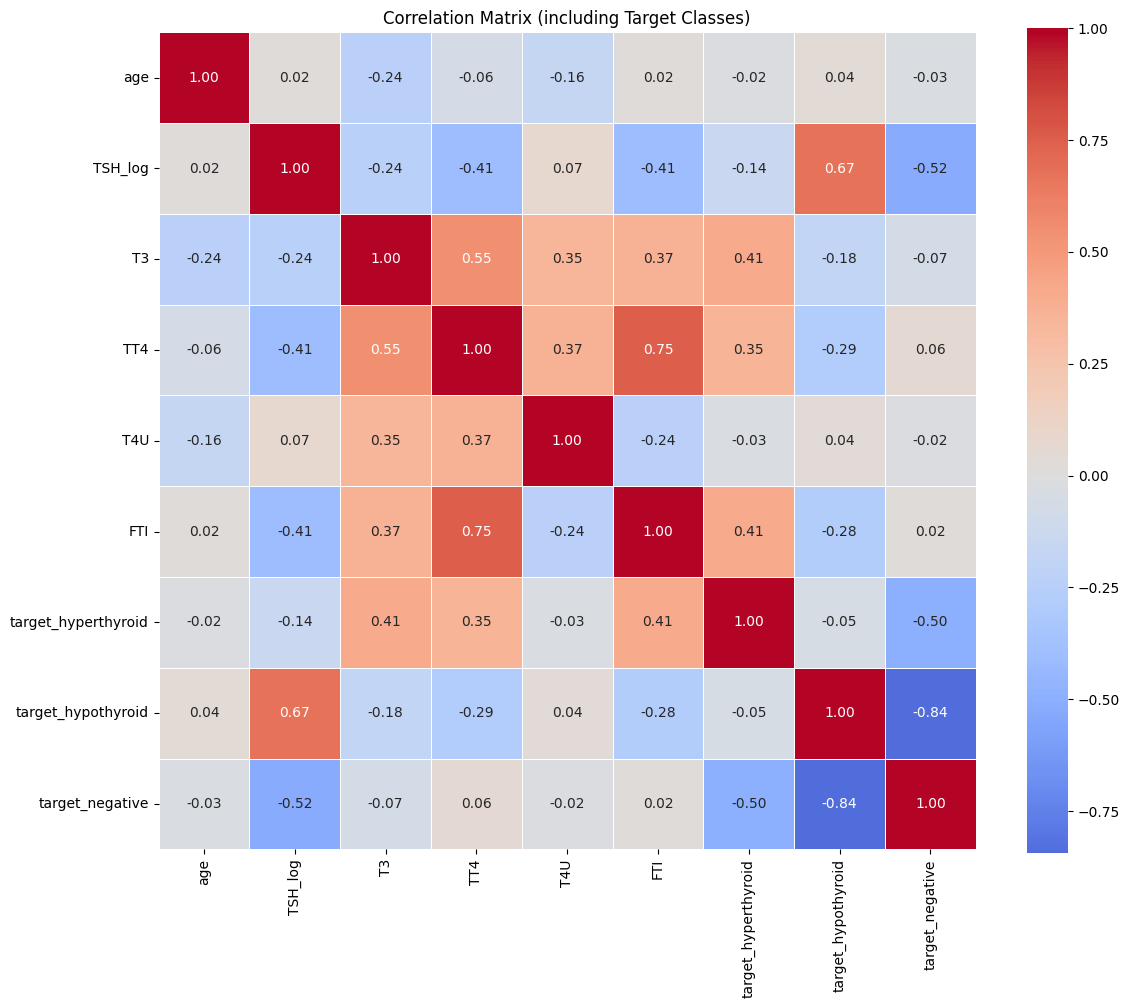

In [ ]:
import seaborn as sns# Create dummy variables for objetivo classestarget_dummies = pd.get_dummies(df['target'], prefix='target').astype(int)# Add dummies to características for correlation analysisdf_corr = pd.concat([df[cleaned_cols], target_dummies], axis=1)correlation_matrix = df_corr.corr()plt.figure(figsize=(12, 10))sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,             fmt='.2f', square=True, linewidths=0.5)plt.title('Correlation Matrix (including Target Classes)')plt.tight_layout()plt.show()

### Interpretación de las Correlaciones
Analizar estas correlaciones nos ayuda a anticipar el comportamiento del modelo y validar la calidad de los datos:

1.  **Multicolinealidad (TT4 y FTI)**:
    - **Observación:** Estas características están extremadamente correlacionadas (> 0.9).
    - **Por qué importa:** FTI se deriva matemáticamente de TT4. Para los modelos lineales (Regresión Logística), esta redundancia puede desestabilizar las estimaciones de coeficientes. Los modelos basados en árboles son robustos ante esto, pero debemos ser conscientes de que la importancia de características podría repartirse entre ellos.

2.  **Señales de Diagnóstico (correlaciones con el objetivo)**:
    - **TSH vs. Hipotiroideo:** Esperamos una **correlación positiva**. Biológicamente, el TSH alto indica que la glándula pituitaria está urgiendo a una tiroides hipoactiva.
    - **T3/TT4 vs. Hipertiroideo:** Esperamos una **correlación positiva**. El hipertiroidismo se define por la producción excesiva de estas hormonas.
    - **T3/TT4 vs. Hipotiroideo:** Esperamos una **correlación negativa** (deficiencia hormonal).

3.  **Factor Edad**:
    - **Observación:** La edad frecuentemente muestra una correlación lineal débil con clases específicas.
    - **Implicación:** Aunque no es un marcador diagnóstico por sí solo como el TSH, la edad es clínicamente relevante ya que la prevalencia varía por etapa de vida. Su valor probablemente proviene de **interacciones** (p. ej., los niveles de TSH podrían tener umbrales diferentes en adultos mayores).

## Perspectivas Clave para el Preprocesamiento

Basándonos en nuestro análisis exploratorio, identificamos varios requisitos de preprocesamiento:

1. **Desequilibrio de Clases**: ~92.5% de casos negativos requieren una selección cuidadosa de métricas (Recall/F1) y división estratificada.

2. **Necesidades de Ingeniería de Características**:
   - **TSH**: Altamente sesgado, se beneficia de una transformación logarítmica.
   - **Edad**: Contiene imposibilidades físicas (>100). Requiere recorte o eliminación de valores atípicos.
   - **TBG**: La columna numérica tiene ~96% de valores faltantes y debe eliminarse. Sin embargo, la bandera `TBG_measured` contiene una señal valiosa y debe conservarse como predictor.
   - **Valores Faltantes**: T3, T4 y FTI tienen ausencias moderadas que probablemente son Faltantes Al Azar (MAR), aptas para imputación.

Estas especificaciones forman los requisitos para el **Pipeline de Preprocesamiento** que construiremos en el siguiente notebook.